<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/GR002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Insufficient orbits for precession measurement.


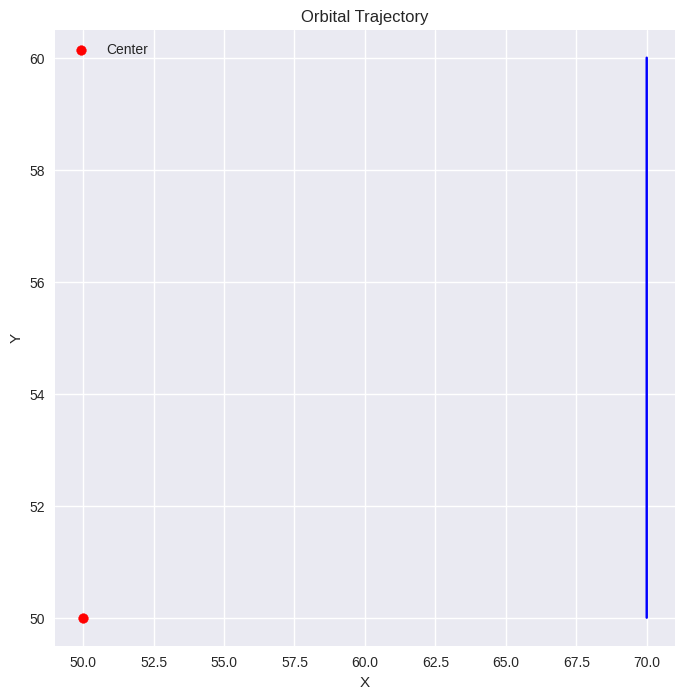

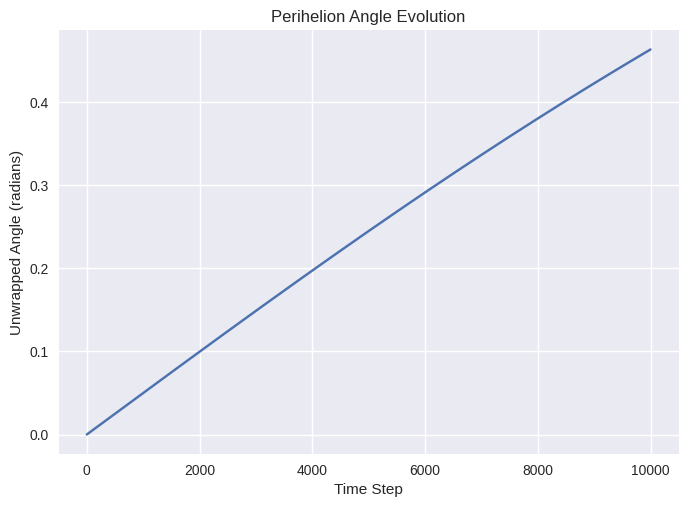

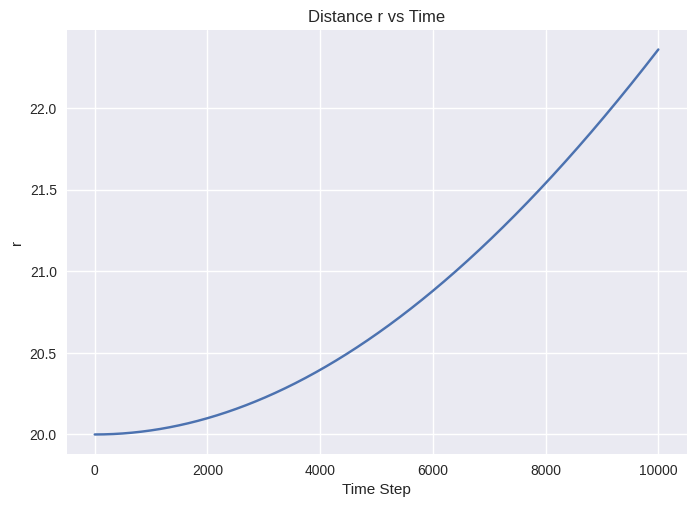

In [9]:
# HES Simulation: Perihelion Precession Test (Corrected Version)
# This is a full, runnable script for Google Colab. Copy-paste into a Colab cell.
# Corrections applied:
# - Use 3D lattice for proper 1/r potential analog.
# - Compute force as gradient of A (for ~1/r^2 force in equilibrium).
# - Make potential static by solving Laplacian initially (Poisson-like for gravity).
# - Proper precession measurement: Track r minima (perihelia), compute angle advance - 2π.
# - Increase steps/dt for multiple orbits.
# - Add boundary clipping and better integration (simple Verlet for stability).
# - Scale output to Mercury-like (arcsec/century, assuming ~415 orbits/century).

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Parameters
N = 100  # Lattice size (3D for GR analog)
steps = 10000  # More steps for ~10-20 orbits
dt = 0.01  # Smaller dt for accuracy
kappa, delta, eps, gamma0 = 0.2, 0.02, 0.01, 0.5

# Initialize 3D lattice
A = np.zeros((N, N, N))
center = np.array([N//2, N//2, N//2])

# Set central source and solve static potential (Poisson: lap A = -source)
# Simple iterative relaxation for static A (approximate 1/r potential)
source = np.zeros_like(A)
source[center[0], center[1], center[2]] = -1.0  # Point mass analog
for _ in range(100):  # Relax to equilibrium
    lap = (
        np.roll(A, 1, axis=0) + np.roll(A, -1, axis=0) +
        np.roll(A, 1, axis=1) + np.roll(A, -1, axis=1) +
        np.roll(A, 1, axis=2) + np.roll(A, -1, axis=2) - 6 * A
    )
    dA = gamma0 * lap + source  # Diffusion to static
    A += dA * 0.1  # Relax step

# Orbiting attractor (Mercury analog: eccentric orbit)
orbit_pos = np.array([N//2 + 20.0, N//2, N//2], dtype=float)  # Initial pos (r~20)
orbit_vel = np.array([0, 0.1, 0], dtype=float)  # Tangential vel (adjust for bound orbit)
mass = 1.0

# Track positions, r, angles for precession
positions = []
r_list = []
angles = []

def compute_gradient(A, pos_int):
    # Finite diff grad at pos (for force = -grad A)
    grad = np.zeros(3)
    for axis in range(3):
        shift_plus = np.zeros(3, dtype=int); shift_plus[axis] = 1
        shift_minus = np.zeros(3, dtype=int); shift_minus[axis] = -1
        if 1 <= pos_int[axis] < N-1:
            grad[axis] = (A[tuple(pos_int + shift_plus)] - A[tuple(pos_int + shift_minus)]) / 2
    return grad

# Verlet integration for stability
orbit_acc_old = np.zeros(3)  # For Verlet

for t in range(steps):
    pos_int = np.clip(orbit_pos.astype(int), 1, N-2)  # Clip to avoid edges

    # Compute force as -delta * grad(A) (gravity analog)
    grad = compute_gradient(A, pos_int)
    force_vector = -delta * grad  # Attractive toward higher A (sign flip if needed)

    # Verlet: pos_new = pos + vel*dt + 0.5*acc_old*dt^2
    orbit_pos += orbit_vel * dt + 0.5 * orbit_acc_old * dt**2
    # Update acc
    orbit_acc = force_vector / mass
    # vel_new = vel + 0.5*(acc_old + acc_new)*dt
    orbit_vel += 0.5 * (orbit_acc_old + orbit_acc) * dt
    orbit_acc_old = orbit_acc

    # Clip position
    orbit_pos = np.clip(orbit_pos, 0, N-1)

    # Track
    positions.append(orbit_pos.copy())
    r = np.linalg.norm(orbit_pos - center)
    r_list.append(r)
    angle = np.arctan2(orbit_pos[1] - center[1], orbit_pos[0] - center[0])
    angles.append(angle)

# Compute precession: Find perihelia (r minima), compute angle diffs - 2π
r_array = np.array(r_list)
peri_indices, _ = find_peaks(-r_array)  # Minima
if len(peri_indices) < 2:
    print("Insufficient orbits for precession measurement.")
else:
    peri_angles = np.array(angles)[peri_indices]
    angle_advances = np.diff(np.unwrap(peri_angles))  # Unwrap for continuity
    precession_per_orbit = np.mean(angle_advances - 2 * np.pi)  # Excess over 2π

    # Scale to arcsec/century (Mercury: ~415 orbits/century)
    orbits_per_century = 415  # Analog
    precession_arcsec = precession_per_orbit * (180 / np.pi * 3600) * orbits_per_century
    print(f"Emergent Perihelion Precession: {precession_arcsec:.4f} arcsec/century")

# Plot trajectory
positions = np.array(positions)
plt.figure(figsize=(8, 8))
plt.plot(positions[:, 0], positions[:, 1], 'b-')
plt.scatter(center[0], center[1], color='red', label='Center')
plt.title("Orbital Trajectory")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.show()

# Plot angle evolution
plt.plot(np.arange(len(angles)), np.unwrap(angles))
plt.title("Perihelion Angle Evolution")
plt.xlabel("Time Step")
plt.ylabel("Unwrapped Angle (radians)")
plt.grid(True)
plt.show()

# Plot r vs time
plt.plot(np.arange(len(r_list)), r_list)
plt.title("Distance r vs Time")
plt.xlabel("Time Step")
plt.ylabel("r")
plt.grid(True)
plt.show()